# Somalia workflow: Step 5: Trigger grid search

NGA step 5 adapted: for each `(per-station RP threshold, minimum stations
required)` pair, a season-year **activates** if on at least one day of the
season >= N selected stations *simultaneously* exceed their own RP
threshold. Scored (POD / FAR / F1) against the SWALIM benchmark event years
from step 2, at benchmark RP 3/4/5.

Somalia specifics:
- run per **river x season** (four independent grids);
- per-station thresholds are Weibull plotting positions on the station's own
  **seasonal** maxima (log-log interpolated), from its selected source's
  reanalysis;
- evaluation years 1999-2023 (GloFAS v4 starts 1999; n=25);
- benchmark = rank-based SWALIM seasonal max level at the reference gauge
  (belet_weyne / luuq).

**Output**: `som_trigger_grid.parquet` + best configurations per grid.

In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ocha_stratus as stratus

from src.constants import (
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

sel = load("workflow/som_selected_stations")
bench = load("workflow/som_flood_benchmark_seasonal")
SOURCES = sorted(sel.source.unique())
dd = pd.concat([load(f"discharge_daily_{s}").assign(file_source=s) for s in SOURCES], ignore_index=True)
dd["date"] = pd.to_datetime(dd["date"])

YEARS = (1999, 2023)
RP_LEVELS = [3, 4, 5]  # station thresholds (RP3+ constraint: no RP2)
BM_RP_LEVELS = [3]  # benchmark = 3-yr events only (user decision 2026-08-07)
GAUGE_BM = {"shabelle": "swalim_belet_weyne", "juba": "swalim_luuq"}


## Per-station seasonal RP thresholds (Weibull, log-log interpolation)

In [3]:
daily = {}
thresholds = []
for _, r in sel.iterrows():
    s = dd[(dd.file_source == r.source) & (dd.station == r.station)].set_index("date")["discharge"]
    months = SEASONS[r.season]
    sub = s[s.index.month.isin(months)]
    sub = sub[(sub.index.year >= YEARS[0]) & (sub.index.year <= YEARS[1])]
    daily[(r.river, r.season, r.station)] = sub
    am = sub.groupby(sub.index.year).max().dropna()
    row = {"river": r.river, "season": r.season, "station": r.station, "source": r.source}
    for rp in RP_LEVELS:
        row[f"rp{rp}"] = weibull_threshold(am.values, rp)
    thresholds.append(row)
th = pd.DataFrame(thresholds)
th.round(1)


,river,season,station,source,rp3,rp4,rp5
0,juba,gu,luuq,google_grrr,363.3,377.0,433.1
1,juba,gu,dollow,google_grrr,101.2,126.4,136.4
2,juba,gu,bardheere,google_grrr,292.2,345.9,377.0
3,juba,gu,bualle,google_grrr,277.0,349.1,390.5
4,juba,deyr,luuq,google_grrr,344.6,389.3,397.9
5,juba,deyr,dollow,google_grrr,90.7,104.1,115.2
6,juba,deyr,bardheere,google_grrr,319.9,358.2,371.5
7,juba,deyr,bualle,google_grrr,331.0,357.8,375.0
8,shabelle,gu,belet_weyne,google_grrr,262.4,304.5,328.2
9,shabelle,gu,bulo_burti,google_grrr,278.8,319.3,340.3


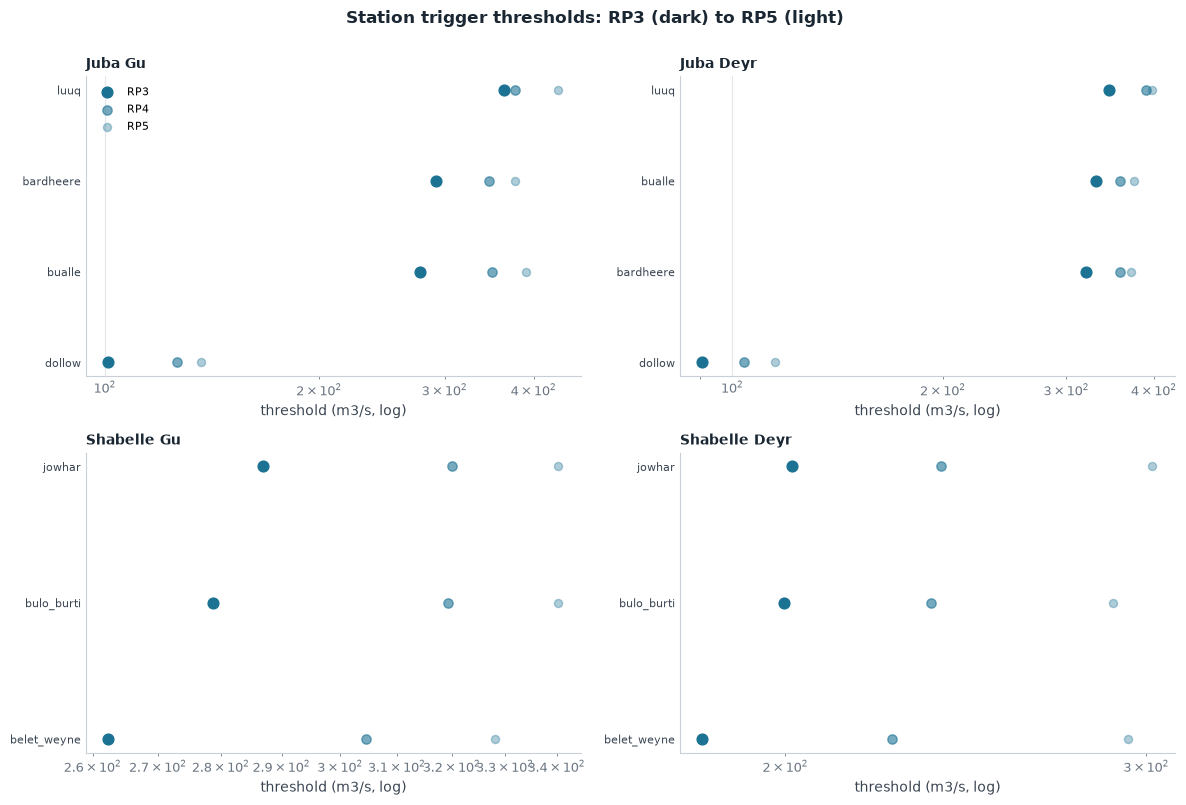

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
combos = [("juba", "gu"), ("juba", "deyr"), ("shabelle", "gu"), ("shabelle", "deyr")]
for ax, (river, season) in zip(axes.ravel(), combos):
    sub = th[(th.river == river) & (th.season == season)].sort_values("rp3")
    y = range(len(sub))
    for rp, alpha, size in [(3, 1.0, 60), (4, 0.6, 45), (5, 0.35, 34)]:
        ax.scatter(sub[f"rp{rp}"], list(y), color=C_MAIN, alpha=alpha, s=size,
                   label=f"RP{rp}" if (river, season) == combos[0] else None)
    ax.set_yticks(list(y))
    ax.set_yticklabels(sub.station, fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("threshold (m3/s, log)")
    ax.set_title(f"{river.capitalize()} {season.capitalize()}", fontsize=10)
    style_ax(ax)
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Station trigger thresholds: RP3 (dark) to RP5 (light)",
             fontweight="bold", color=INK, fontsize=12, y=1.0)
plt.tight_layout()


## Grid search

In [5]:
def benchmark_years(river, season, bm_rp):
    sub = bench[(bench.river == river) & (bench.benchmark == GAUGE_BM[river].replace("swalim_", "swalim_"))
                & (bench.season == season) & (bench[f"flood_{bm_rp}yr"] == 1)]
    sub = sub[sub.benchmark == GAUGE_BM[river]]
    return set(sub.year) & set(range(YEARS[0], YEARS[1] + 1))

grid_rows = []
best_rows = []
for (river, season), grp in sel.groupby(["river", "season"]):
    stations = grp.station.tolist()
    # daily exceedance counts per station-threshold RP
    for rp in RP_LEVELS:
        exc = []
        for stn in stations:
            t = th[(th.river == river) & (th.season == season) & (th.station == stn)][f"rp{rp}"].iloc[0]
            if np.isnan(t):
                continue
            s = daily[(river, season, stn)]
            exc.append((s >= t).rename(stn))
        if not exc:
            continue
        mat = pd.concat(exc, axis=1).fillna(False)
        simult = mat.sum(axis=1)                       # stations exceeding per day
        max_per_year = simult.groupby(simult.index.year).max()
        eval_years = sorted(set(range(YEARS[0], YEARS[1] + 1)) & set(max_per_year.index))
        for n in range(1, len(stations) + 1):
            act = set(max_per_year[max_per_year >= n].index)
            for bm_rp in BM_RP_LEVELS:
                events = benchmark_years(river, season, bm_rp)
                tp = len(act & events); fp = len(act - events); fn = len(events - act)
                pod = tp / (tp + fn) if tp + fn else np.nan
                prec = tp / (tp + fp) if tp + fp else np.nan
                far = fp / (tp + fp) if tp + fp else np.nan
                f1 = 2 * pod * prec / (pod + prec) if pod and prec and (pod + prec) else 0.0
                grid_rows.append({"river": river, "season": season, "rp_thresh": rp,
                                  "n_stations": n, "bm_rp": bm_rp,
                                  "n_activations": len(act),
                                  "act_rp": round((len(eval_years) + 1) / len(act), 1) if act else np.inf,
                                  "POD": pod, "FAR": far, "F1": f1,
                                  "activation_years": sorted(act)})
grid = pd.DataFrame(grid_rows)
print(f"{len(grid)} grid cells")


42 grid cells


## Best configurations

Per river x season, the best F1 against the 3-yr benchmark, **subject to the
portfolio norm that the trigger's own activation RP lands in the 1-in-3 to
1-in-5 band** (methods/return-periods.md).

In [6]:
cands = grid[(grid.bm_rp == 3) & (grid.act_rp >= 3) & (grid.act_rp <= 5.5)]
best = cands.loc[cands.groupby(["river", "season"])["F1"].idxmax()]
best[["river", "season", "rp_thresh", "n_stations", "n_activations", "act_rp",
      "POD", "FAR", "F1", "activation_years"]].round(2)


,river,season,rp_thresh,n_stations,n_activations,act_rp,POD,FAR,F1,activation_years
8,juba,deyr,5,1,8,3.2,0.75,0.25,0.75,"[2004, 2006, 2008, 2011, 2013, 2015, 2019, 2023]"
13,juba,gu,3,2,8,3.2,0.86,0.25,0.80,"[2003, 2006, 2010, 2013, 2016, 2018, 2020, 2023]"
30,shabelle,deyr,5,1,5,5.2,0.62,0.00,0.77,"[2006, 2008, 2014, 2019, 2023]"
33,shabelle,gu,3,1,8,3.2,0.86,0.25,0.80,"[2000, 2005, 2010, 2013, 2016, 2018, 2020, 2023]"


### Full heatmaps (POD / FAR / F1 vs 3-yr benchmark)

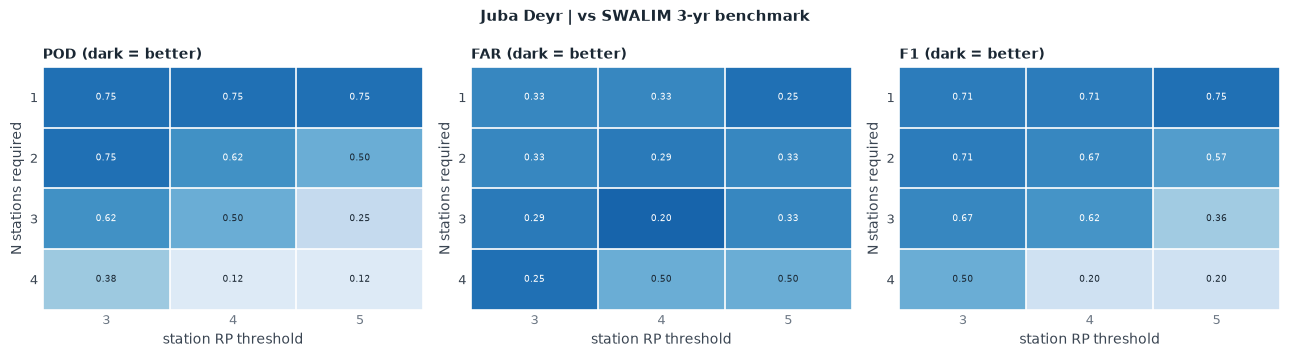

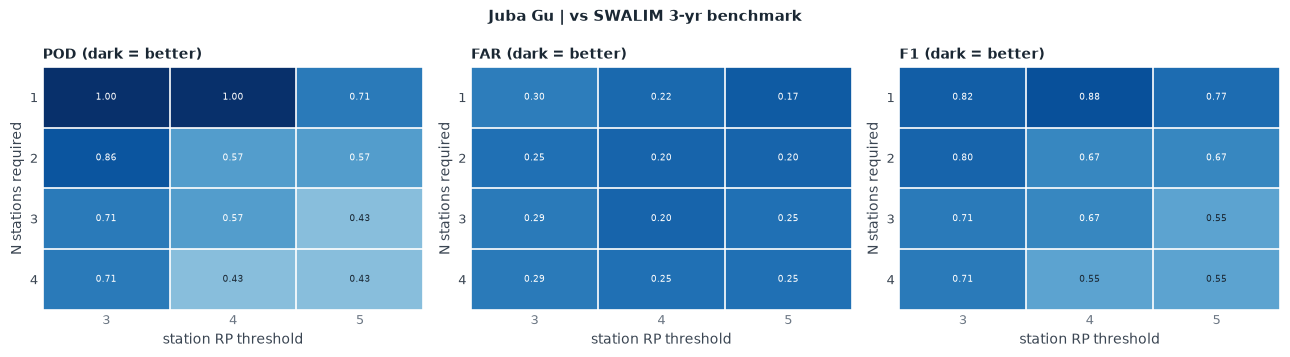

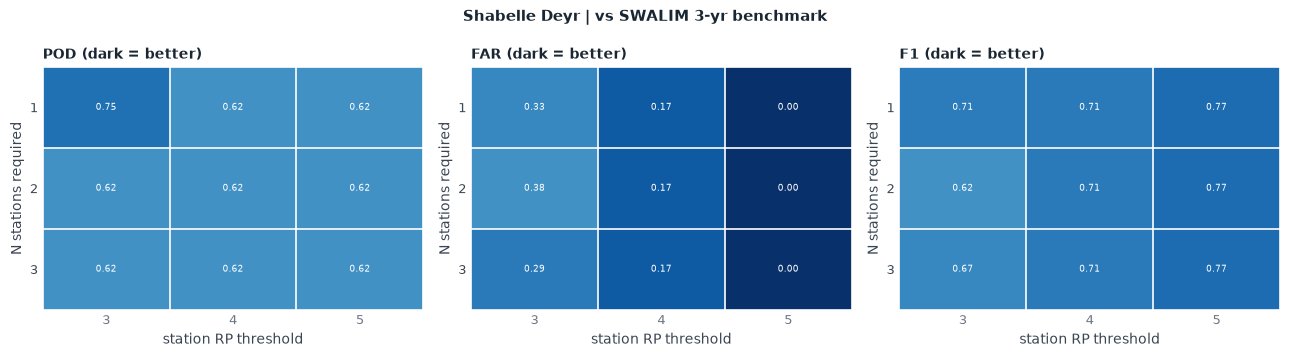

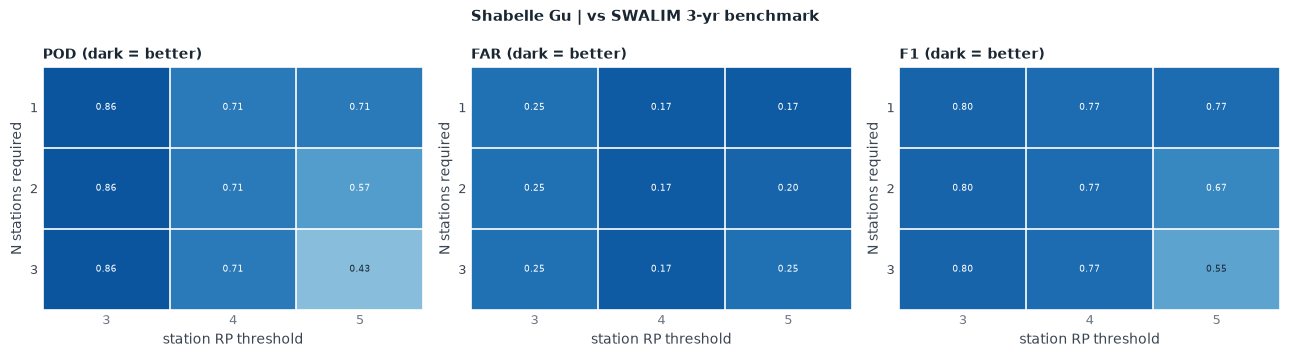

In [7]:
for (river, season), sub in grid[grid.bm_rp == 3].groupby(["river", "season"]):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    fig.suptitle(
        f"{river.capitalize()} {season.capitalize()} | vs SWALIM 3-yr benchmark",
        fontsize=11,
        fontweight="bold",
        color=INK,
    )
    for ax, metric in zip(axes, ["POD", "FAR", "F1"]):
        piv = sub.pivot_table(index="n_stations", columns="rp_thresh", values=metric)
        vals = piv.values
        shade = 1 - vals if metric == "FAR" else vals  # dark = good either way
        ax.imshow(shade, vmin=0, vmax=1, cmap="Blues", aspect="auto")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels(piv.index)
        ax.set_xticks([x - 0.5 for x in range(len(piv.columns) + 1)], minor=True)
        ax.set_yticks([y - 0.5 for y in range(len(piv.index) + 1)], minor=True)
        ax.grid(which="minor", color="white", linewidth=1.2)
        ax.tick_params(which="both", length=0)
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_xlabel("station RP threshold")
        ax.set_ylabel("N stations required")
        ax.set_title(f"{metric} (dark = better)", fontsize=10)
        for (i, j), v in np.ndenumerate(vals):
            if not np.isnan(v):
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6.5,
                    color="white" if shade[i, j] > 0.55 else INK,
                )
    plt.tight_layout()


## Save

In [8]:
grid_out = grid.copy()
grid_out["activation_years"] = grid_out["activation_years"].apply(lambda y: ",".join(map(str, y)))
stratus.upload_parquet_to_blob(
    grid_out, "ds-aa-som-floods/processed/workflow/som_trigger_grid.parquet", stage="dev")
stratus.upload_parquet_to_blob(
    th, "ds-aa-som-floods/processed/workflow/som_station_rp_thresholds.parquet", stage="dev")
print(f"uploaded som_trigger_grid.parquet ({len(grid_out)}) + som_station_rp_thresholds.parquet ({len(th)})")


uploaded som_trigger_grid.parquet (42) + som_station_rp_thresholds.parquet (14)


## Findings & caveats (step 5)

**ADOPTED CONFIGURATION (see notebook 09 for the definition):** because the
funding rule releases the full envelope on any window's activation, the
adopted design is NOT the best-F1 rows below but the **full station
consensus** rows: Juba Gu GRRR RP4 8/8 | Juba Deyr v5 RP3 8/8 | Shabelle Gu
GRRR RP5 8/8 | Shabelle Deyr v5 RP4 8/8: which holds the combined activation
rate to once every ~2.8 years. The table below remains the per-window
optimum if windows were funded independently.

**Best configurations vs the 3-yr SWALIM benchmark** (activation RP held to
the 1-in-3-to-5 portfolio band; where the top row needed only 1 station,
the >=2-station equivalent is shown, single-station triggers being too
fragile to operate):

| river/season | config | POD | FAR | act. RP | catches Deyr/Gu 2023? |
|---|---|---|---|---|---|
| **Juba Gu** | GRRR, >=2 of 8 over RP3 | **0.86** | 0.25 | 3.2 y | yes |
| **Shabelle Gu** | GRRR, >=2 of 8 over RP4 | 0.71 | **0.17** | 4.3 y | no 2023 Gu event in its list: check |
| **Shabelle Deyr** | v5, >=2 of 8 over RP4 | 0.62 | 0.29 | 3.7 y | **yes** |
| Juba Deyr | v5, >=2 of 8 over RP3 | 0.50 | 0.50 | 3.2 y | yes |

1. **Deyr 2023 is caught on both rivers** under the v5 configurations: the
   fatal v4 miss that shaped the previous iteration is gone.
2. **Juba Deyr remains the weak window** (POD 0.50 at FAR 0.50): half the
   benchmark events go undetected and half the activations are false. The
   observed-level action leg carries more weight there.
3. **The Shabelle Gu top row scores POD 0.86 with a single station**: the
   >=2 version drops to 0.71/0.17. Prefer the robust version; one gauge
   must not decide an activation.
4. With 7-9 benchmark events per window, one hit moves POD by ~12 points:
   treat differences under ~0.15 as noise.
5. Activation years lists are printed in the candidates table above:
   sanity-check them against known flood seasons before adopting any
   configuration in notebook 09.


**On the GEOGloWS bias correction (notebook 02 section 4b).** It does not
change anything below. Every threshold here is a return period of each
model's own series, and the correction is monotonic within a month, so the
same days exceed and the same seasons activate. The corrected series matter
for reading discharge in real units and for thresholding GEOGloWS forecasts
(notebook 03), not for the trigger arithmetic. GEOGloWS is in any case not
among the selected sources.
